<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Computer Graphics
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Line Clipping Algorithm
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

# What is Clipping?

## In the context of computer graphics, clipping is a method to enable or disable the rendering operations within a defined region/area. We can simply say it is a technique for what to show and what not to do that will reduce the computation cost. Similarly, a rendering algorithm only fills the pixels within an intersection line, designated, or defined region.

# Cohen–Sutherland Line Clipping Algorithm
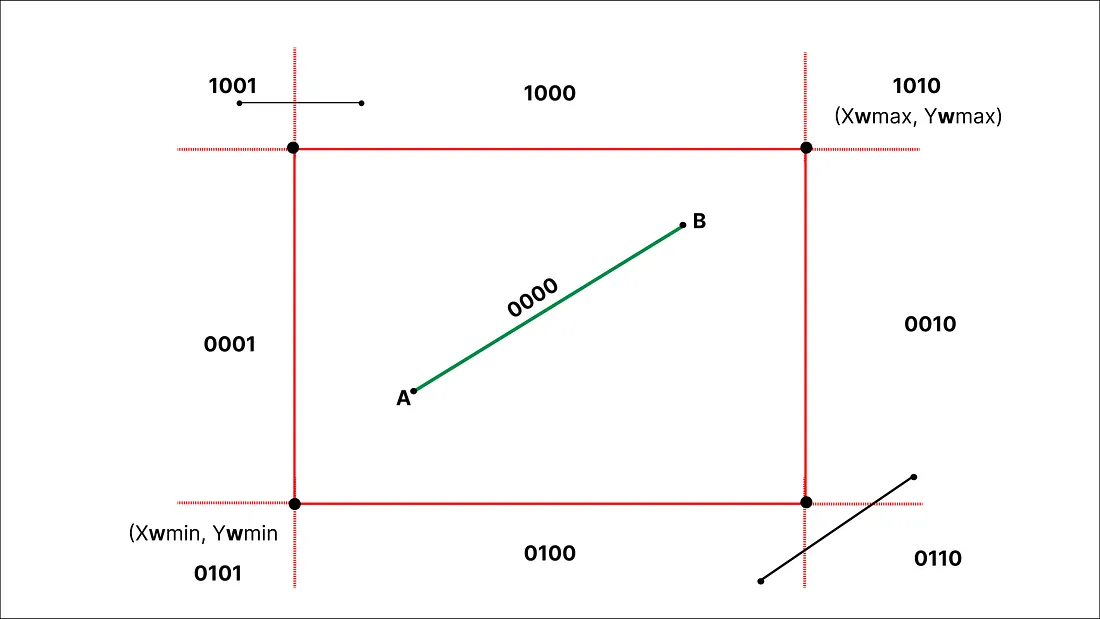
## Algorithm Steps

### 1) Assign region codes

* Assign the **region codes** to both endpoints of the line using `compute_code(x, y)`.

### 2) Perform OR operation

* Perform **bitwise OR** on the region codes of both endpoints.

### 3) Check OR result

* **If OR = 0000**
  → The line is **completely visible** (inside the window).

* **Else**
  → Perform **bitwise AND** on both endpoints:

  1. **If AND ≠ 0000**
     → The line is **completely invisible** (outside the window) and **cannot be clipped**.

  2. **If AND = 0000**
     → The line is **partially inside** the window and **needs clipping**.

### 4) Find intersection with window boundary

* After confirming the line is partially inside, calculate intersection points with window boundaries using the **line slope**:

```text
Slope: m = (y2 - y1) / (x2 - x1)
```

#### a) Top boundary

* If the line intersects **top boundary**:

```text
x = x1 + (y_wmax – y1)/m
y = y_wmax
```

#### b) Bottom boundary

* If the line intersects **bottom boundary**:

```text
x = x1 + (y_wmin – y1)/m
y = y_wmin
```

#### c) Left boundary

* If the line intersects **left boundary**:

```text
y = y1 + (x_wmin – x1)*m
x = x_wmin
```

#### d) Right boundary

* If the line intersects **right boundary**:

```text
y = y1 + (x_wmax – x1)*m
x = x_wmax
```
### 5) Update endpoints

* Replace the **outside endpoint** with the new intersection point.
* Update its **region code** accordingly.

### 6) Repeat

* Repeat **step 4** until the line is either:

  * Completely inside the window (accept), or
  * Completely outside the window (reject).

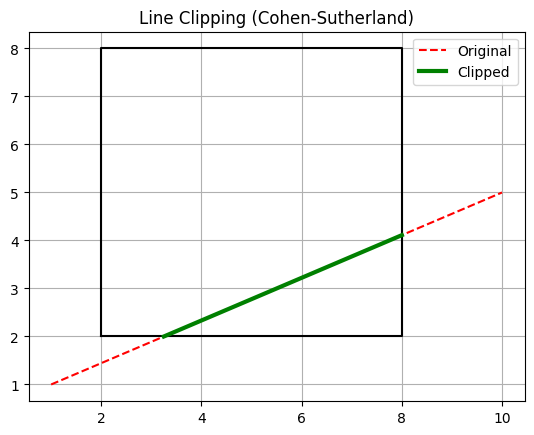

In [2]:
import matplotlib.pyplot as plt

# TBRL 
# Define region codes
INSIDE = 0  # 0000
LEFT   = 1  # 0001
RIGHT  = 2  # 0010
BOTTOM = 4  # 0100
TOP    = 8  # 1000

# Clipping window
x_min, y_min = 2, 2
x_max, y_max = 8, 8

def compute_code(x, y):
    code = INSIDE

    if x < x_min:
        code |= LEFT
    elif x > x_max:
        code |= RIGHT
    if y < y_min:
        code |= BOTTOM
    elif y > y_max:
        code |= TOP

    return code

def cohen_sutherland(x1, y1, x2, y2):
    code1 = compute_code(x1, y1)
    code2 = compute_code(x2, y2)

    accept = False

    while True:
        if code1 == 0 and code2 == 0:  # Both Inside
            accept = True
            break
        elif (code1 & code2) != 0:   # If (code1 & code2) != 0 Then Completely Outside 
            break
        else:
            x, y = 0, 0

            # Code outside of the Window
            if code1 != 0:
                code_out = code1
            else:
                code_out = code2

            if code_out & TOP:
                x = x1 + (x2 - x1) * (y_max - y1) / (y2 - y1)
                y = y_max
            elif code_out & BOTTOM:
                x = x1 + (x2 - x1) * (y_min - y1) / (y2 - y1)
                y = y_min
            elif code_out & RIGHT:
                y = y1 + (y2 - y1) * (x_max - x1) / (x2 - x1)
                x = x_max
            elif code_out & LEFT:
                y = y1 + (y2 - y1) * (x_min - x1) / (x2 - x1)
                x = x_min

            if code_out == code1:
                x1, y1 = x, y
                code1 = compute_code(x1, y1)
            else:
                x2, y2 = x, y
                code2 = compute_code(x2, y2)

    if accept:
        return x1, y1, x2, y2
    else:
        return None


# Original line
x1, y1 = 1, 1
x2, y2 = 10, 5

# Clipped line
result = cohen_sutherland(x1, y1, x2, y2)

# Draw window
plt.plot([x_min, x_max, x_max, x_min, x_min],
         [y_min, y_min, y_max, y_max, y_min], 'k-')

# Draw original line (red)
plt.plot([x1, x2], [y1, y2], 'r--', label='Original')

# Draw clipped line (green)
if result:
    x1c, y1c, x2c, y2c = result
    plt.plot([x1c, x2c], [y1c, y2c], 'g', linewidth=3, label='Clipped')

plt.legend()
plt.title("Line Clipping (Cohen-Sutherland)")
plt.grid()
plt.show()